# Assignment 3 – Matplotlib & Seaborn

1. Explain: Data Cleaning & Preprocessing 
* Load the dataset and check for missing values. 
* Fill missing Age values with median or mean. 
* Handle missing Embarked values by filling with the most common port. 
* Drop unnecessary columns like Name, Ticket, Cabin for visualization purposes.  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df = pd.read_csv(r"C:\Users\ramanyadav\OneDrive\Documents\Data Analytics Assignments\train.csv")   #loading dataset 

In [5]:
df    

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [8]:
df.isnull()        # Check missing values

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
df['Age'].fillna(df['Age'].median(), inplace=True)  # Fill missing Age values with median

In [10]:
df['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [12]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)   # Fill missing Embarked values with mode  

C:\Users\ramanyadav\AppData\Local\Temp\ipykernel_15712\3972906332.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)   # Fill missing Embarked values with mode


In [13]:
df['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [14]:
df.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)    # Drop unnecessary columns


In [15]:
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S
887,888,1,1,female,19.0,0,0,30.0000,S
888,889,0,3,female,28.0,1,2,23.4500,S
889,890,1,1,male,26.0,0,0,30.0000,C


In [16]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

2. Univariate Analysis 
* Plot the distribution of Age using a histogram and a KDE plot. 
* Plot the count of passengers by Sex using a bar chart. 
* Show the distribution of Fare using a boxplot.

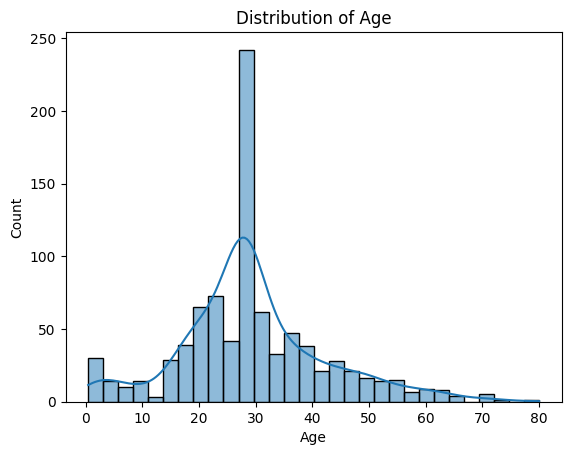

In [27]:
#distribution of Age using a histogram and a KDE plot
sns.histplot(df['Age'],kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

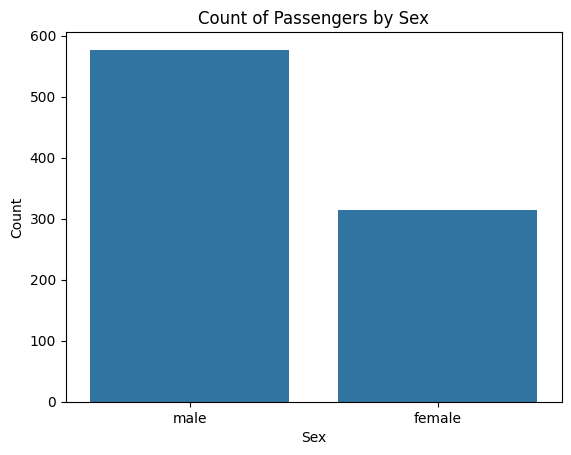

In [30]:
#count of passengers by Sex using a bar chart
sns.countplot(x='Sex', data=df)
plt.title("Count of Passengers by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

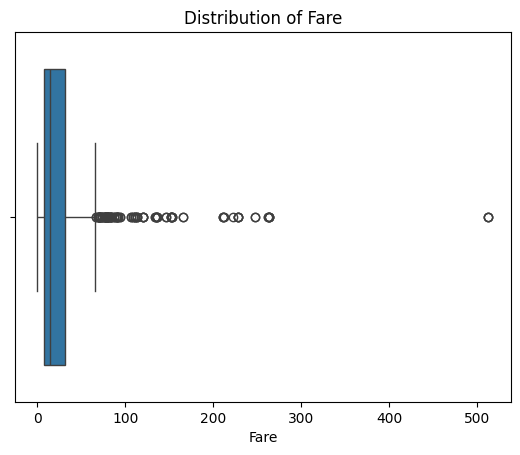

In [26]:
#distribution of Fare using a boxplot
sns.boxplot(x=df['Fare'])
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.show()

3. Bivariate Analysis 
* Compare survival rate across Sex using a countplot. 
* Compare Pclass vs Fare using a boxplot. 
* Visualize Age vs Fare using a scatter plot, color-coded by Survived.  

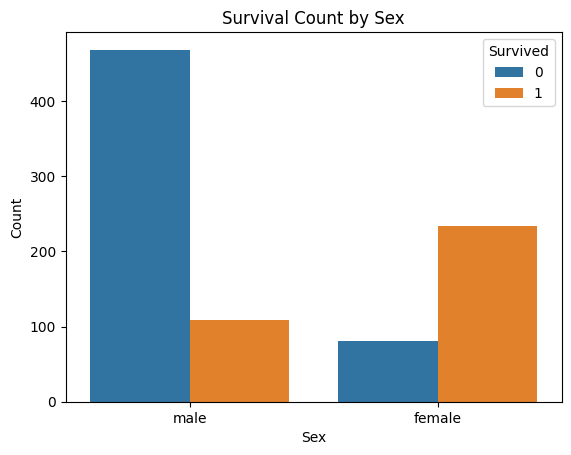

In [32]:
#urvival rate across Sex using a countplot
sns.countplot(x='Sex', data=df, hue='Survived')
plt.title("Survival Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Survived")
plt.show()


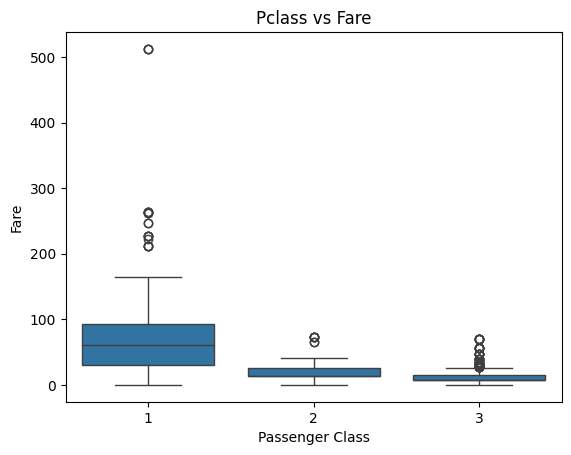

In [33]:
# Pclass vs Fare using a boxplot
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title("Pclass vs Fare")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

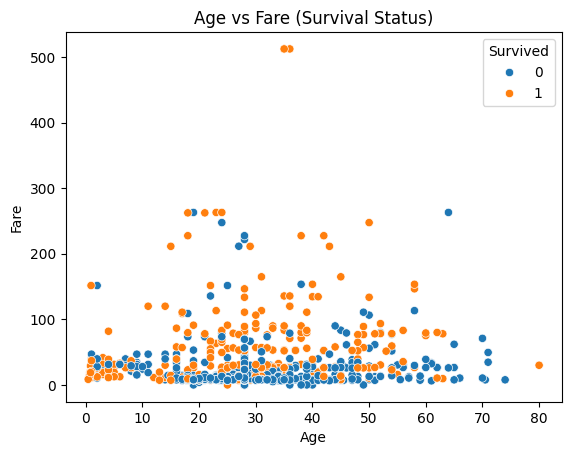

In [34]:
#Age vs Fare using a scatter plot, color-coded by Survived
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title("Age vs Fare (Survival Status)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()